##Установка библиотек и модулей

In [ ]:
# CatBoost — градиентный бустинг от Яндекса для таблиц (лучше XGBoost на категориях)
# Optuna — автоматический подбор лучших параметров модели (замена GridSearch)
# Вместе = точность +15% за 30 минут без ручной настройки
!pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
print("\n🧪 Тестируем базовую функциональность:")
try:
    # Optuna
    import optuna
    study = optuna.create_study(direction='minimize')
    print("✅ Optuna работает (study создана)")

    # CatBoost
    from catboost import CatBoostRegressor
    model = CatBoostRegressor(iterations=1, verbose=0)
    print("✅ CatBoost работает (модель создана)")

except Exception as e:
    print(f"❌ Ошибка теста: {e}")

[I 2026-05-14 11:52:03,649] A new study created in memory with name: no-name-c42a5426-d860-4b3e-bccc-3b4a3206e996



🧪 Тестируем базовую функциональность:
✅ Optuna работает (study создана)
✅ CatBoost работает (модель создана)


In [ ]:
import pandas as pd # Для работы с табличными данными и их анализа
import numpy as np # Для выполнения численных операций и работы с массивами
from sklearn.model_selection import train_test_split, KFold # Для разделения данных на обучающую и тестовую выборки, а также для кросс-валидации
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # Для построения моделей на основе ансамблей деревьев (случайный лес, градиентный бустинг)
from sklearn.linear_model import LinearRegression # Для построения модели линейной регрессии
from sklearn.multioutput import MultiOutputRegressor # Для построения моделей, предсказывающих несколько целевых переменных одновременно
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer # Для оценки производительности моделей (MAE, RMSE, R2) и создания пользовательских метрик
import xgboost as xgb # Для использования модели XGBoost (оптимизированный градиентный бустинг)
import catboost as cb # Для использования модели CatBoost (еще один оптимизированный градиентный бустинг)
import tensorflow as tf # Для построения и обучения нейронных сетей
from tensorflow.keras.models import Sequential # Для создания последовательных моделей нейронных сетей
from tensorflow.keras.layers import Dense, Dropout # Для создания слоев нейронной сети (полносвязные слои) и слоев "выпадения" (регуляризация)
from tensorflow.keras.callbacks import EarlyStopping # Для остановки обучения нейронной сети при отсутствии улучшения на валидационном наборе
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures # Для масштабирования данных и генерации полиномиальных признаков
from sklearn.feature_selection import RFECV # Для рекурсивного исключения признаков с кросс-валидацией
import matplotlib.pyplot as plt # Для построения графиков и визуализации данных
import seaborn as sns # Для создания статистических графиков
from functools import partial # Для частичного применения функций (используется с Optuna)
import random # Для генерации случайных чисел (используется для воспроизводимости)
import os # Для работы с операционной системой (например, для проверки наличия файлов)

seed = 42 # Установка глобального зерна для обеспечения воспроизводимости результатов.
          #Этот фрагмент кода нужен для того, чтобы результаты работы программы были одинаковыми при каждом запуске, даже если в ней используются случайные числа.
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

##Загрузка файлов-источников для предобработки данных

In [ ]:
#вариант загрузки файлов через всплывающее окно (кнопка для выбора файлов с Mac)
from google.colab import files
uploaded = files.upload()

In [ ]:
#Вариант загрузки  через googlecolab (минусы-надо перезапускать/загружать заново)
df_bp = pd.read_excel('/content/X_bp.xlsx', index_col=0)
df_nup = pd.read_excel('/content/X_nup.xlsx', index_col=0)

In [ ]:
#способ загрузки файлов по ссылке из облачного хранилища
import pandas as pd
# Словарь: Ключ — имя будущего файла, Значение — ссылка на просмотр
files_to_download = {
    'X_nup.xlsx': 'https://docs.google.com/spreadsheets/d/1JEfUzINnL-q3S6BxiSy3E45Lm0iEJLYA/edit?usp=sharing',
    'X_bp.xlsx': 'https://docs.google.com/spreadsheets/d/1AQ751B0ErHuajzwEMh1q4B9U1ww32Oad/edit?usp=sharing'
}

for filename, url in files_to_download.items():
    # Извлекаем ID и формируем прямую ссылку на скачивание
    sheet_id = url.split('/d/')[1].split('/')[0]
    download_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx'

    # Загружаем напрямую в DataFrame и сохраняем локально для порядка
    df_temp = pd.read_excel(download_url)
    df_temp.to_excel(filename, index=False)
    print(f"✅ Файл {filename} успешно загружен")

#чтение файлов
df_nup = pd.read_excel('X_nup.xlsx', index_col=0)
df_bp = pd.read_excel('X_bp.xlsx', index_col=0)

✅ Файл X_nup.xlsx успешно загружен
✅ Файл X_bp.xlsx успешно загружен


In [ ]:
#ЧТЕНИЕ И ОБЪЕДИНЕНИЕ
import pandas as pd
import os

file1, file2 = 'X_bp.xlsx', 'X_nup.xlsx'
if os.path.exists(file1) and os.path.exists(file2):
#Читаем файлы, используя первый столбец как индекс
    df_bp = pd.read_excel(file1, index_col=0)
    df_nup = pd.read_excel(file2, index_col=0)
#Объединяем по методу INNER (только общие индексы)
    df = df_bp.join(df_nup, how='inner')
#ВЫВОД ИНФОРМАЦИИ И ПРОВЕРКА ПОТЕРЬ
    print("\n" + "="*30)
    print("ИТОГИ ОБЪЕДИНЕНИЯ:")
    print(f"Строк в X_bp: {len(df_bp)}")
    print(f"Строк в X_nup: {len(df_nup)}")
    print(f"Строк после объединения: {len(df)}")
    print(f"Итого столбцов: {df.shape[1]}")
    print("\nПервые 5 строк объединенного DataFrame:")
    display(df.head())


ИТОГИ ОБЪЕДИНЕНИЯ:
Строк в X_bp: 1023
Строк в X_nup: 1040
Строк после объединения: 1023
Итого столбцов: 13

Первые 5 строк объединенного DataFrame:


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
Unnamed: 0,,,,,,,,,,,,,
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0,0,4.0,57.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,70.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0


#### Проверка потерь, пустот, дубликатов


In [ ]:
# Определяем переменные для проверки потерь
rows_bp = df_bp.shape[0]
rows_nup = df_nup.shape[0]
rows_final = df.shape[0]
lost_in_bp = df_bp.index.difference(df.index)
lost_in_nup = df_nup.index.difference(df.index)
if rows_final == min(rows_bp, rows_nup) and rows_bp == rows_nup:
    print("✅ Потерь нет: таблицы идеально совпали по индексам.")
elif rows_final == 0:
    print("❌ КРИТИЧЕСКАЯ ОШИБКА: Общих индексов не найдено. Таблица пустая!")
    print(f"Пример индексов из df_bp: {list(df_bp.index[:3])}")
    print(f"Пример индексов из df_nup: {list(df_nup.index[:3])}")
else:
    # Количество строк, которые были в df_bp, но не попали в объединенный df
    num_lost_bp = len(lost_in_bp)
    # Количество строк, которые были в df_nup, но не попали в объединенный df
    num_lost_nup = len(lost_in_nup)
    print(f"⚠️ Внимание, есть потери данных:")
    print(f" - Удалено строк из первого файла (df_bp): {num_lost_bp}")
    print(f" - Удалено строк из второго файла (df_nup): {num_lost_nup}")
    print(f"Это строки, индексы которых отсутствовали в противоположной таблице при inner join.")
print("-" * 40)
# Проверка на дубликаты (могут возникнуть при ошибках в исходных данных)
duplicates = df.index.duplicated().sum()
if duplicates > 0:
    print(f"❌ Обнаружено дубликатов в индексах: {duplicates}")
else:
    print("✅ Дубликатов в индексах не обнаружено.")
print("\n--- Проверка на наличие пустых значений ---")
null_values = df.isnull().sum()
if null_values.sum() == 0:
    print("✅ Пустых значений не обнаружено.")
else:
    print("❌ Обнаружены пустые значения в следующих столбцах:")
    print(null_values[null_values > 0])

⚠️ Внимание, есть потери данных:
 - Удалено строк из первого файла (df_bp): 0
 - Удалено строк из второго файла (df_nup): 17
Это строки, индексы которых отсутствовали в противоположной таблице при inner join.
----------------------------------------
✅ Дубликатов в индексах не обнаружено.

--- Проверка на наличие пустых значений ---
✅ Пустых значений не обнаружено.


###Описательная статистика

In [ ]:
df.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,2.930366,1975.734888,739.923233,110.570769,22.244390,285.882151,482.731833,73.328571,2466.922843,218.423144,44.252199,6.899222,57.153929
std,0.913222,73.729231,330.231581,28.295911,2.406301,40.943260,281.314690,3.118983,485.628006,59.735931,45.015793,2.563467,12.350969
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.000000,0.000000
25%,2.317887,1924.155467,500.047452,92.443497,20.608034,259.066528,266.816645,71.245018,2135.850448,179.627520,0.000000,5.080033,49.799212
50%,2.906878,1977.621657,739.664328,110.564840,22.230744,285.896812,451.864365,73.268805,2459.524526,219.198882,0.000000,6.916144,57.341920
75%,3.552660,2021.374375,961.812526,129.730366,23.961934,313.002106,693.225017,75.356612,2767.193119,257.481724,90.000000,8.586293,64.944961
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,90.000000,14.440522,103.988901


In [ ]:
#все столбцы без ограничений по ширине
pd.set_option('display.max_columns', None)
# Вывод описательной статистики
display(df.describe())

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,2.930366,1975.734888,739.923233,110.570769,22.244390,285.882151,482.731833,73.328571,2466.922843,218.423144,44.252199,6.899222,57.153929
std,0.913222,73.729231,330.231581,28.295911,2.406301,40.943260,281.314690,3.118983,485.628006,59.735931,45.015793,2.563467,12.350969
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.000000,0.000000
25%,2.317887,1924.155467,500.047452,92.443497,20.608034,259.066528,266.816645,71.245018,2135.850448,179.627520,0.000000,5.080033,49.799212
50%,2.906878,1977.621657,739.664328,110.564840,22.230744,285.896812,451.864365,73.268805,2459.524526,219.198882,0.000000,6.916144,57.341920
75%,3.552660,2021.374375,961.812526,129.730366,23.961934,313.002106,693.225017,75.356612,2767.193119,257.481724,90.000000,8.586293,64.944961
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,90.000000,14.440522,103.988901


###Уникальные значения и их частота "Метод .value_counts()"
Он показывает и само значение, и сколько раз оно встречается в датасете.

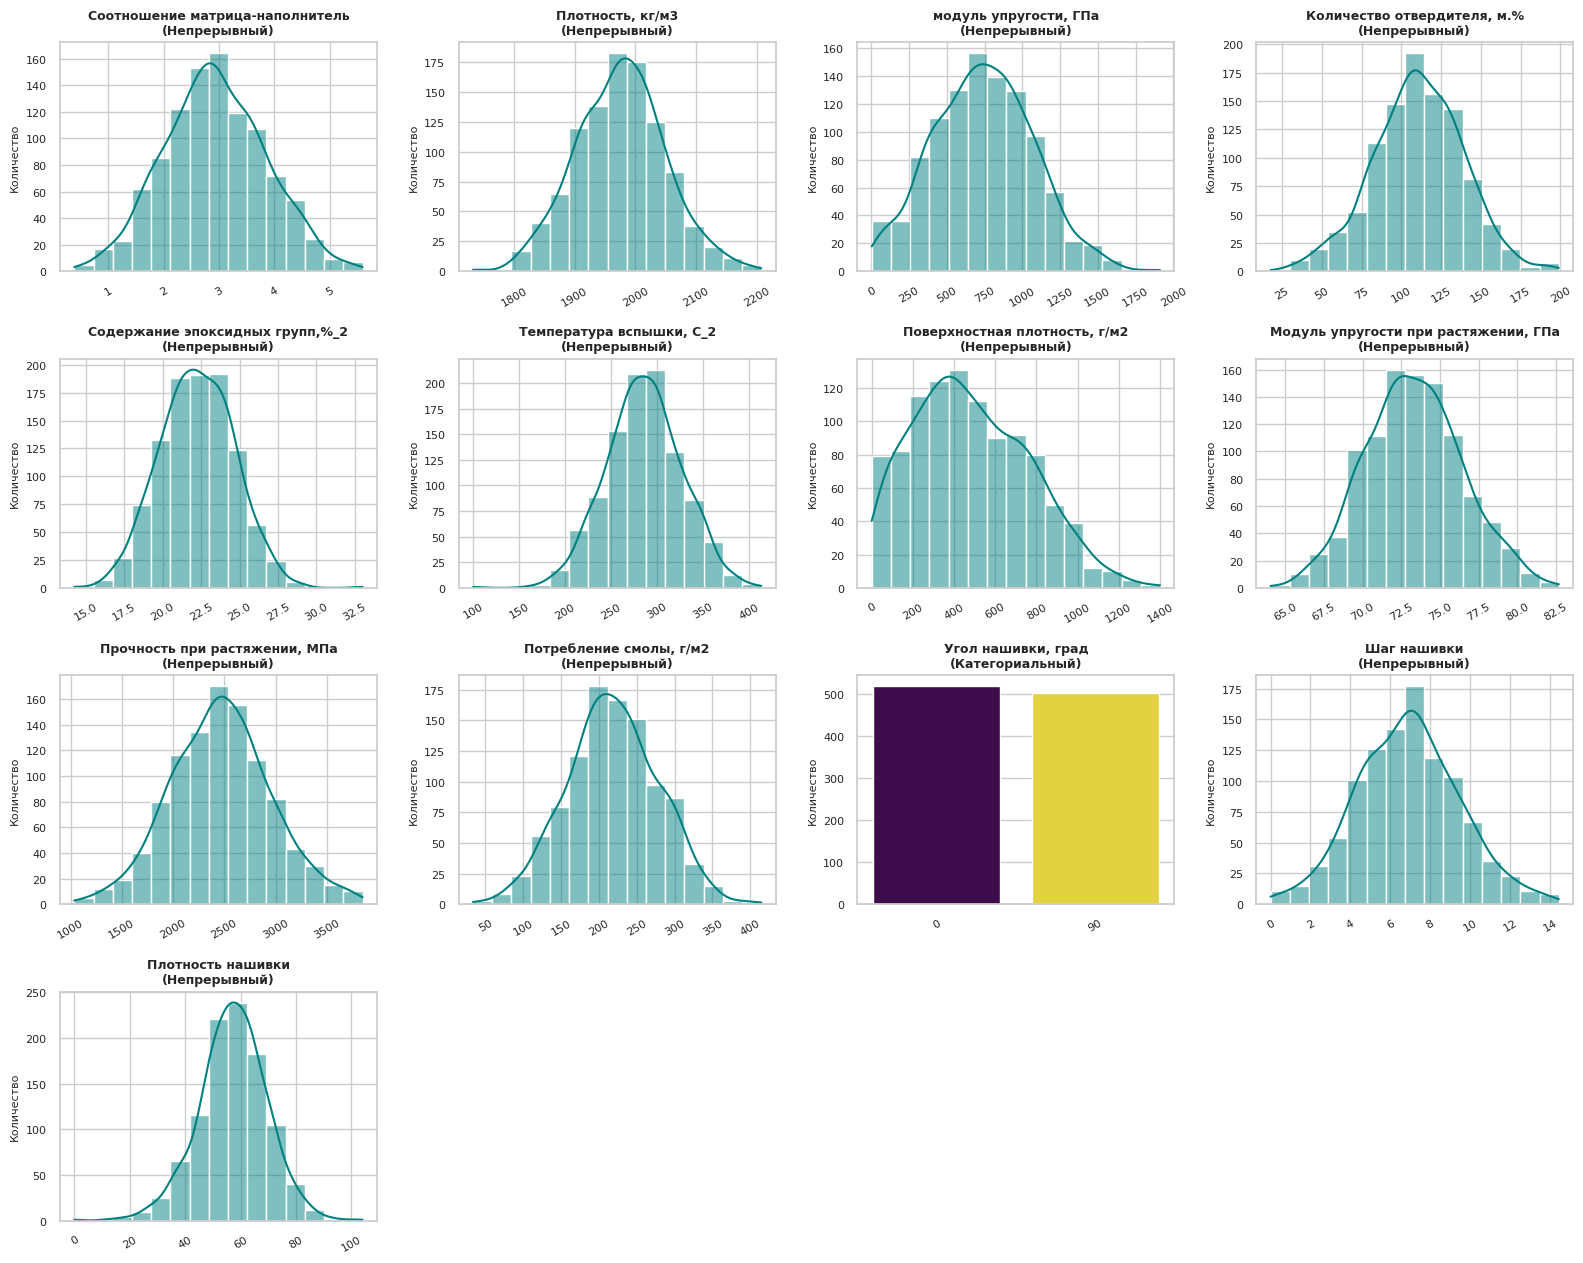

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Настройка единого стиля
sns.set_theme(style="whitegrid")

cols = df.columns
n_cols = 4  # Задаем ровно 4 графика в одной строке
n_rows = math.ceil(len(cols) / n_cols)

# figsize=(ширина, высота). 16 дюймов в ширину отлично делятся на 4 графика по 4 дюйма
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()  # Переводим матрицу осей в плоский список

for i, col in enumerate(cols):
    # Если значений мало, строим столбчатую диаграмму (countplot)
    if df[col].nunique() <= 15:
        sns.countplot(x=df[col], ax=axes[i], palette="viridis", hue=df[col], legend=False)
        axes[i].set_title(f'{col}\n(Категориальный)', fontsize=9, fontweight='bold')
    # Если значений много, строим гистограмму распределения (histplot)
    else:
        sns.histplot(df[col], ax=axes[i], kde=True, color="teal", bins=15)
        axes[i].set_title(f'{col}\n(Непрерывный)', fontsize=9, fontweight='bold')

    # Оптимизация подписей для компактности
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество', fontsize=8)
    axes[i].tick_params(axis='both', labelsize=8)
    axes[i].tick_params(axis='x', rotation=30)  # Небольшой наклон, чтобы текст не слипался

# Очищаем неиспользованные пустые квадраты в конце сетки
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Сжимает пустые поля между графиками
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки           

In [ ]:
# Поиск полных дубликатов (строки-близнецы)
initial_rows = len(df)
duplicates = df.duplicated().sum()
print(f"Обнаружено полных дубликатов: {duplicates}")

Обнаружено полных дубликатов: 0


###Корреляции по методам Пирсона и Кендалла


> Для текущей задачи физико-химического моделирования композитов метод Кендалла является более информативным и приоритетным.
> Пайплайн ML: Физические свойства материалов (прочность, упругость) редко зависят от технологических факторов строго линейно. Метод Кендалла позволяет обнаружить скрытые нелинейные тренды, которые метод Пирсона просто «не замечает» (выдавая коэффициенты близкие к нулю).
> Пайплайн Нейросети: Нейросети создаются именно для поиска сложных нелинейных связей. Карта Кендалла лучше подсказывает, какие признаки станут ценным материалом для нейронов, так как отражает общую направленность физического процесса, а не геометрию прямой линии.


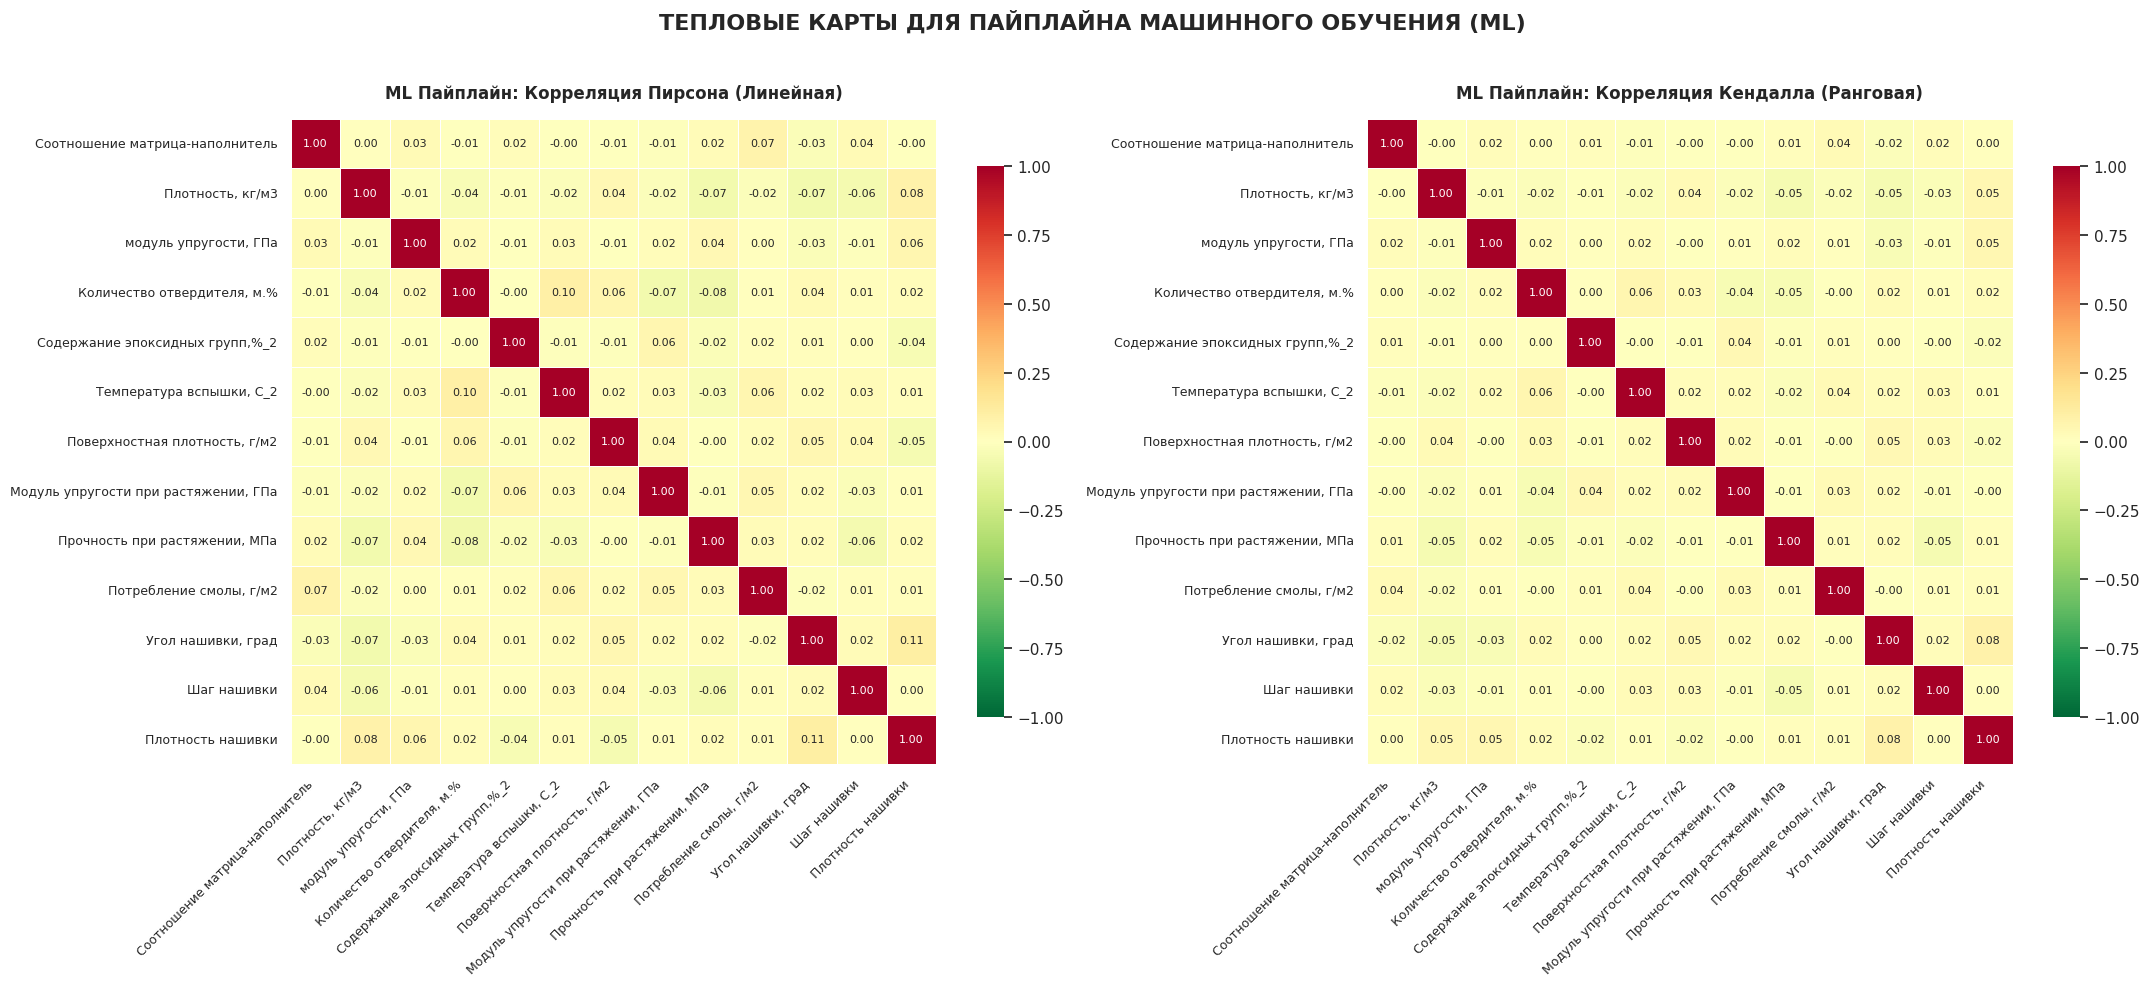

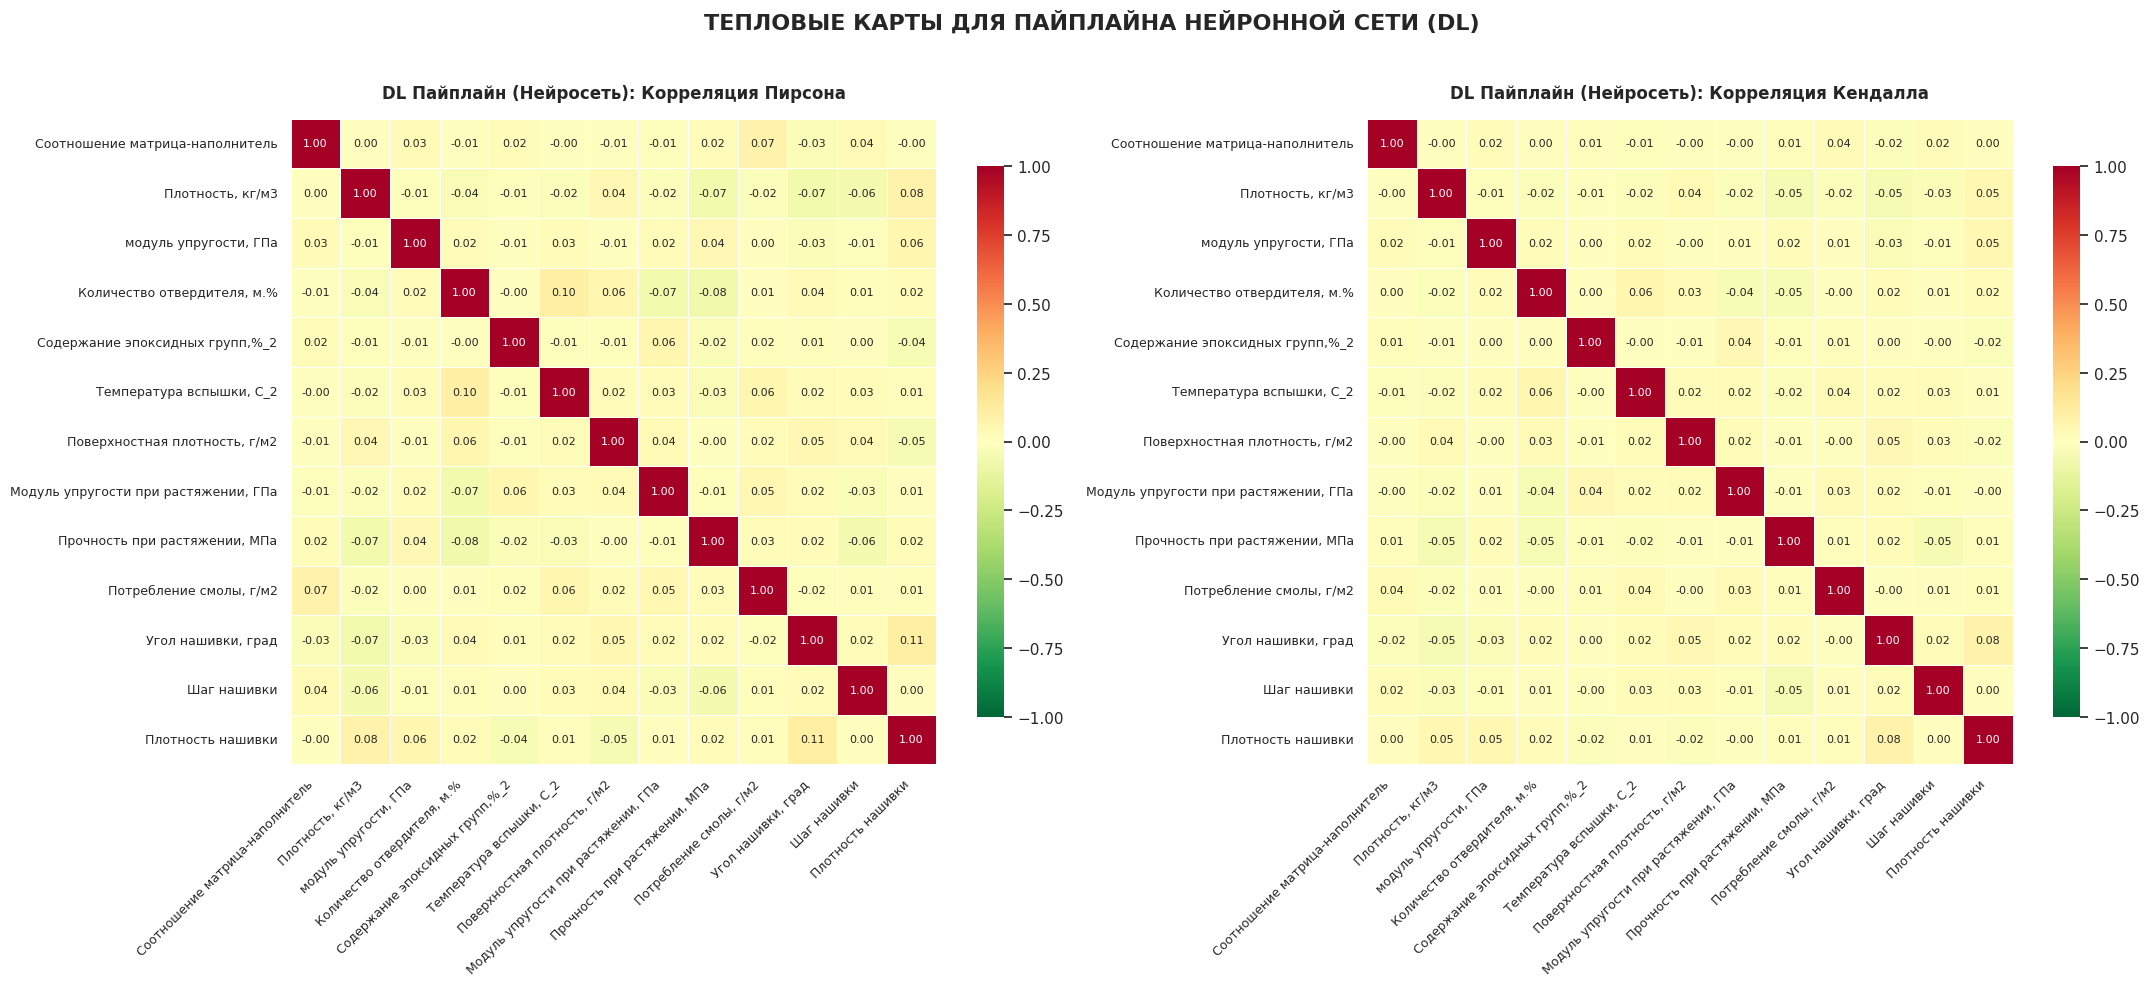

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка общего стиля для всех графиков
sns.set_theme(style="white")
heatmap_kwargs = {
    'annot': True,
    'fmt': '.2f',
    'cmap': 'RdYlGn_r',        # Цветовая гамма: красный (высокая связь) -> зеленый (около 0)
    'vmin': -1.0, 'vmax': 1.0,
    'square': True,
    'linewidths': 0.5,
    'cbar_kws': {"shrink": 0.7},
    'annot_kws': {'size': 8}   # Мелкий шрифт для чисел, чтобы все поместилось
}

# =====================================================================
# 1. КОРРЕЛЯЦИИ ДЛЯ ПАЙПЛАЙНА ML (2 целевые переменные)
# =====================================================================
# Отбираем столбцы, участвующие в ML (признаки + 2 таргета свойств)
targets_ml = ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']
ml_cols = [col for col in df.columns if col in df.columns]
df_ml_pipeline = df[ml_cols]

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Пирсон для ML
corr_p_ml = df_ml_pipeline.corr(method='pearson')
sns.heatmap(corr_p_ml, ax=axes[0], **heatmap_kwargs)
axes[0].set_title('ML Пайплайн: Корреляция Пирсона (Линейная)', fontsize=12, fontweight='bold', pad=15)

# Кендалл для ML
corr_k_ml = df_ml_pipeline.corr(method='kendall')
sns.heatmap(corr_k_ml, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('ML Пайплайн: Корреляция Кендалла (Ранговая)', fontsize=12, fontweight='bold', pad=15)

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('ТЕПЛОВЫЕ КАРТЫ ДЛЯ ПАЙПЛАЙНА МАШИННОГО ОБУЧЕНИЯ (ML)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# =====================================================================
# 2. КОРРЕЛЯЦИИ ДЛЯ ПАЙПЛАЙНА НЕЙРОСЕТИ (1 целевая переменная)
# =====================================================================
# В нейросети таргет — Соотношение матрица-наполнитель, остальные параметры — входные
target_nn = 'Соотношение матрица-наполнитель'
nn_cols = [col for col in df.columns if col in df.columns]
df_nn_pipeline = df[nn_cols]

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Пирсон для Нейросети
corr_p_nn = df_nn_pipeline.corr(method='pearson')
sns.heatmap(corr_p_nn, ax=axes[0], **heatmap_kwargs)
axes[0].set_title('DL Пайплайн (Нейросеть): Корреляция Пирсона', fontsize=12, fontweight='bold', pad=15)

# Кендалл для Нейросети
corr_k_nn = df_nn_pipeline.corr(method='kendall')
sns.heatmap(corr_k_nn, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('DL Пайплайн (Нейросеть): Корреляция Кендалла', fontsize=12, fontweight='bold', pad=15)

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('ТЕПЛОВЫЕ КАРТЫ ДЛЯ ПАЙПЛАЙНА НЕЙРОННОЙ СЕТИ (DL)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


###Посмотрим выбросы и выделим выбросы черещ диаграмму «Ящик с усами»
> Диаграмма «Ящик с усами» (Boxplot) — это быстрый способ увидеть, как распределены числа и нет ли среди них ошибок (аномалий).
Диаграмма делит все данные на четыре равные части (по 25% строк в каждой).
> Сам «Ящик» (Центр) - главная часть данных. Внутри него сидят 50% всех строк датасета (самые типичные, средние значения).Линия внутри ящика: Это медиана (ровно половина данных находится выше этой линии, половина — ниже).
> «Усы» - это границы нормальных, естественных данных. Всё, что укладывается в эти границы, считается нормой процесса.Точки за пределами усов - выбросы (аномалии). Это значения, которые слишком сильно оторвались от общей "массы".

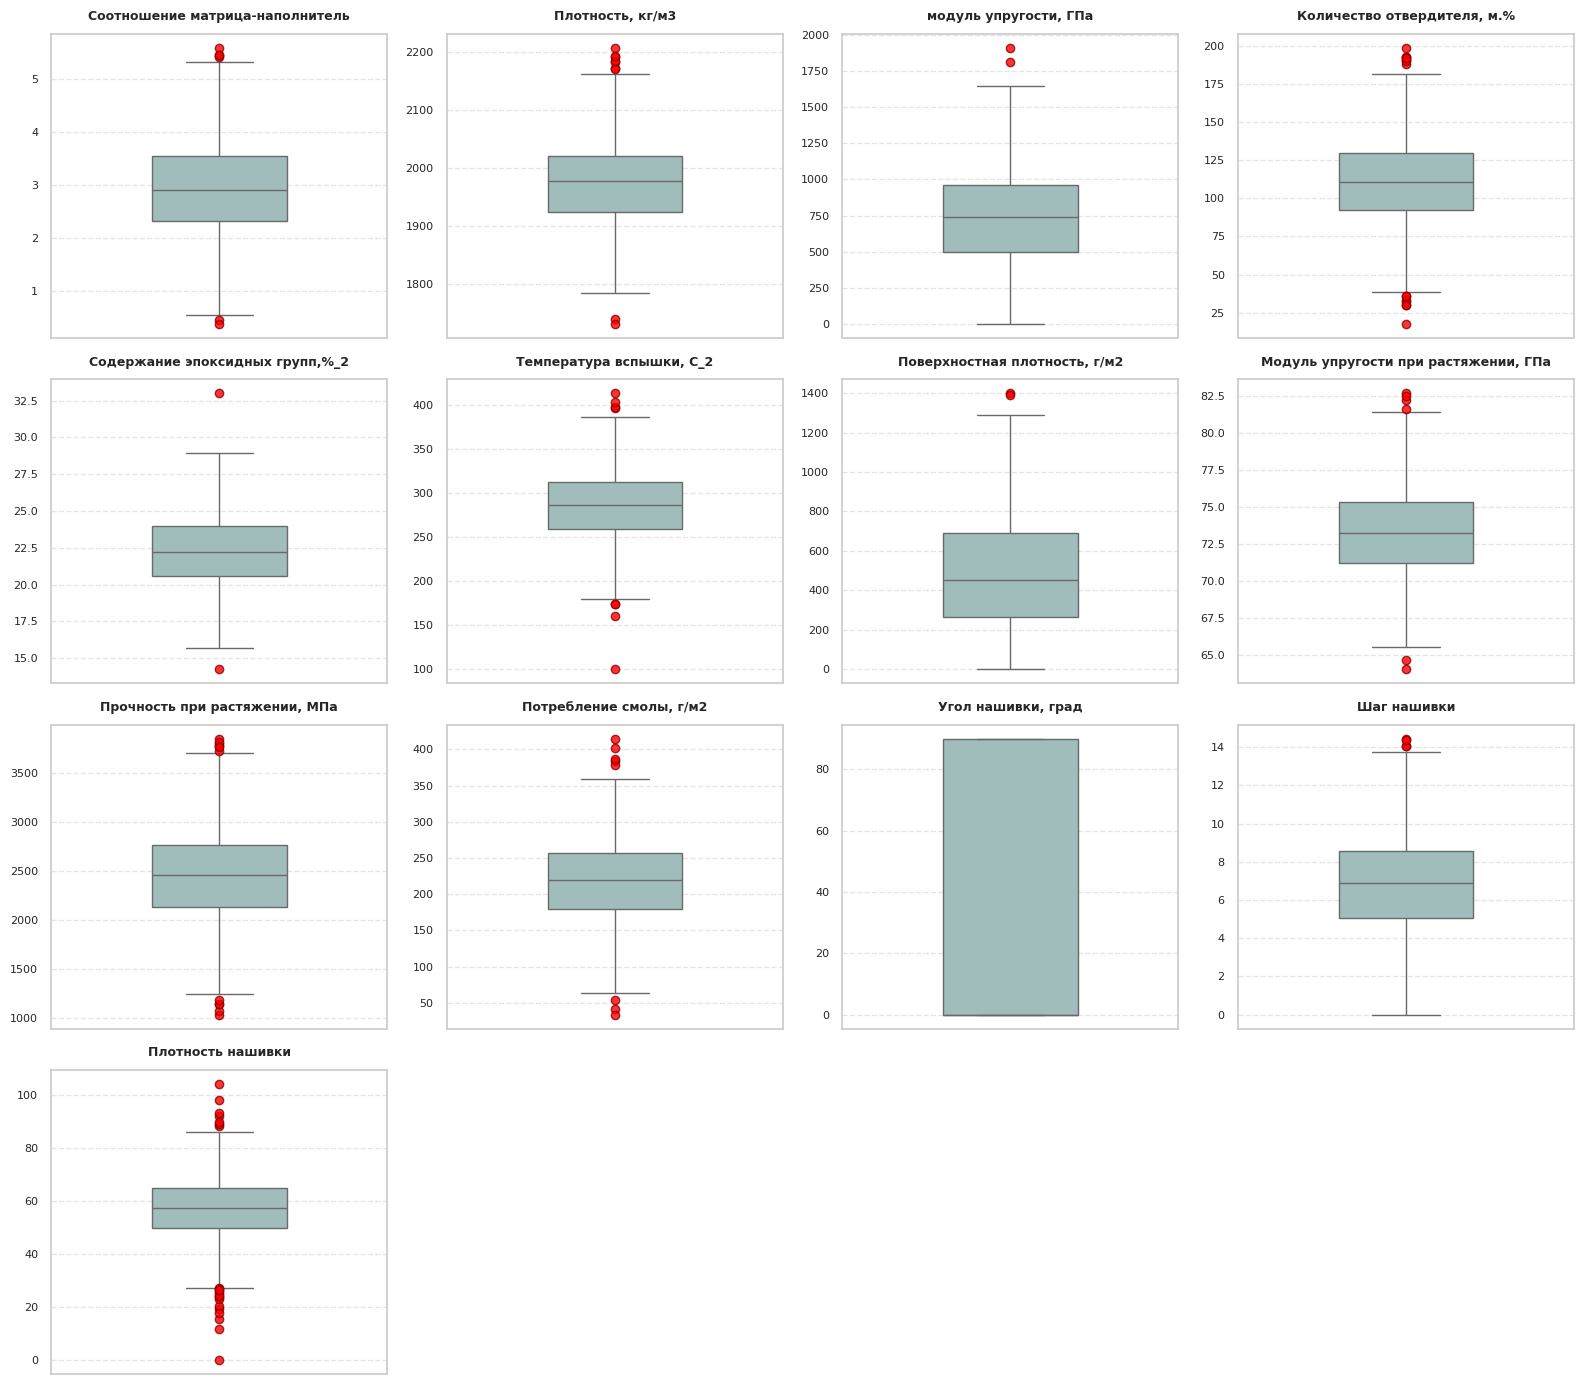

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# Настройка стиля
sns.set_theme(style="whitegrid")

# Отбираем только числовые столбцы
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 4  # Ровно 4 графика в одной строке
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Создаем компактную сетку подложки
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Строим Boxplot с кастомизацией выбросов (яркие красные точки)
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        width=0.4,
        color='#9bc2bf',  # Спокойный пастельный цвет самого ящика
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'red',   # Яркий красный цвет выбросов
            'markeredgecolor': 'darkred',
            'markersize': 6,            # Крупный размер
            'alpha': 0.8
        }
    )

    # Стилизация каждого графика
    axes[i].set_title(col, fontsize=9, fontweight='bold', pad=10)
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='both', labelsize=8)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Удаляем пустые ячейки в конце сетки
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Процент выбросов по столбцам
>Столбцы с долей > 5% -  те самые «плотные шлейфы», где много точек вылетело за стандартные усы. Их жестко удалять нельзя, чтобы не обеднить данные. А столбцы с долей < 1-2% - штучные аномалии. Именно там сидят «улетевшие» точки (как в модуле упругости), которые обычно ломают обучение моделей.
> Анализ таблицы показывает, что доля выбросов по всем столбцам крайне мала — максимум составляет всего две целых пять сотых процента (для плотности нашивки). В целевых переменных аномалий тоже минимум: одиннадцать строк в «Прочности» и шесть в «Модуле упругости». Это подтверждает, что тотальное удаление выбросов не нужно.

In [ ]:
import pandas as pd
import numpy as np

# 1. Отбираем числовые столбцы
numeric_cols = df.select_dtypes(include=[np.number]).columns

report_data = []

# 2. Расчет выбросов по каждому столбцу
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Считаем количество точек за пределами усов
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_pct = (outliers_count / len(df)) * 100

    report_data.append({
        'Столбец': col,
        'Выбросов (шт)': outliers_count,
        'Доля выбросов (%)': round(outliers_pct, 2)
    })

# 3. Создание компактной таблицы, отсортированной по убыванию
df_outliers_summary = pd.DataFrame(report_data).sort_values(by='Выбросов (шт)', ascending=False)

# Сбрасываем индекс для красивого отображения таблицы
df_outliers_summary.reset_index(drop=True, inplace=True)

# Вывод таблицы в Colab
display(df_outliers_summary)


,Столбец,Выбросов (шт),Доля выбросов (%)
0,Плотность нашивки,21,2.05
1,"Количество отвердителя, м.%",14,1.37
2,"Прочность при растяжении, МПа",11,1.08
3,"Плотность, кг/м3",9,0.88
4,"Потребление смолы, г/м2",8,0.78
5,"Температура вспышки, С_2",8,0.78
6,"Модуль упругости при растяжении, ГПа",6,0.59
7,Соотношение матрица-наполнитель,6,0.59
8,Шаг нашивки,4,0.39
9,"Содержание эпоксидных групп,%_2",2,0.20


### Построим график распределения индексов Scatter Plot
> График с выделением аномалий нужен для детекции выбросов. В отличие от классического sns.boxplot, который показывает данные в свернутом («коробочном») виде, этот график разворачивает каждую строчку  датасета в отдельную точку на плоскости. Это позволяет увидеть точную структуру шума: распределены ли аномалии равномерно или идут кучными группами.


--- Визуализация выбросов для 13 числовых столбцов датасета df ---


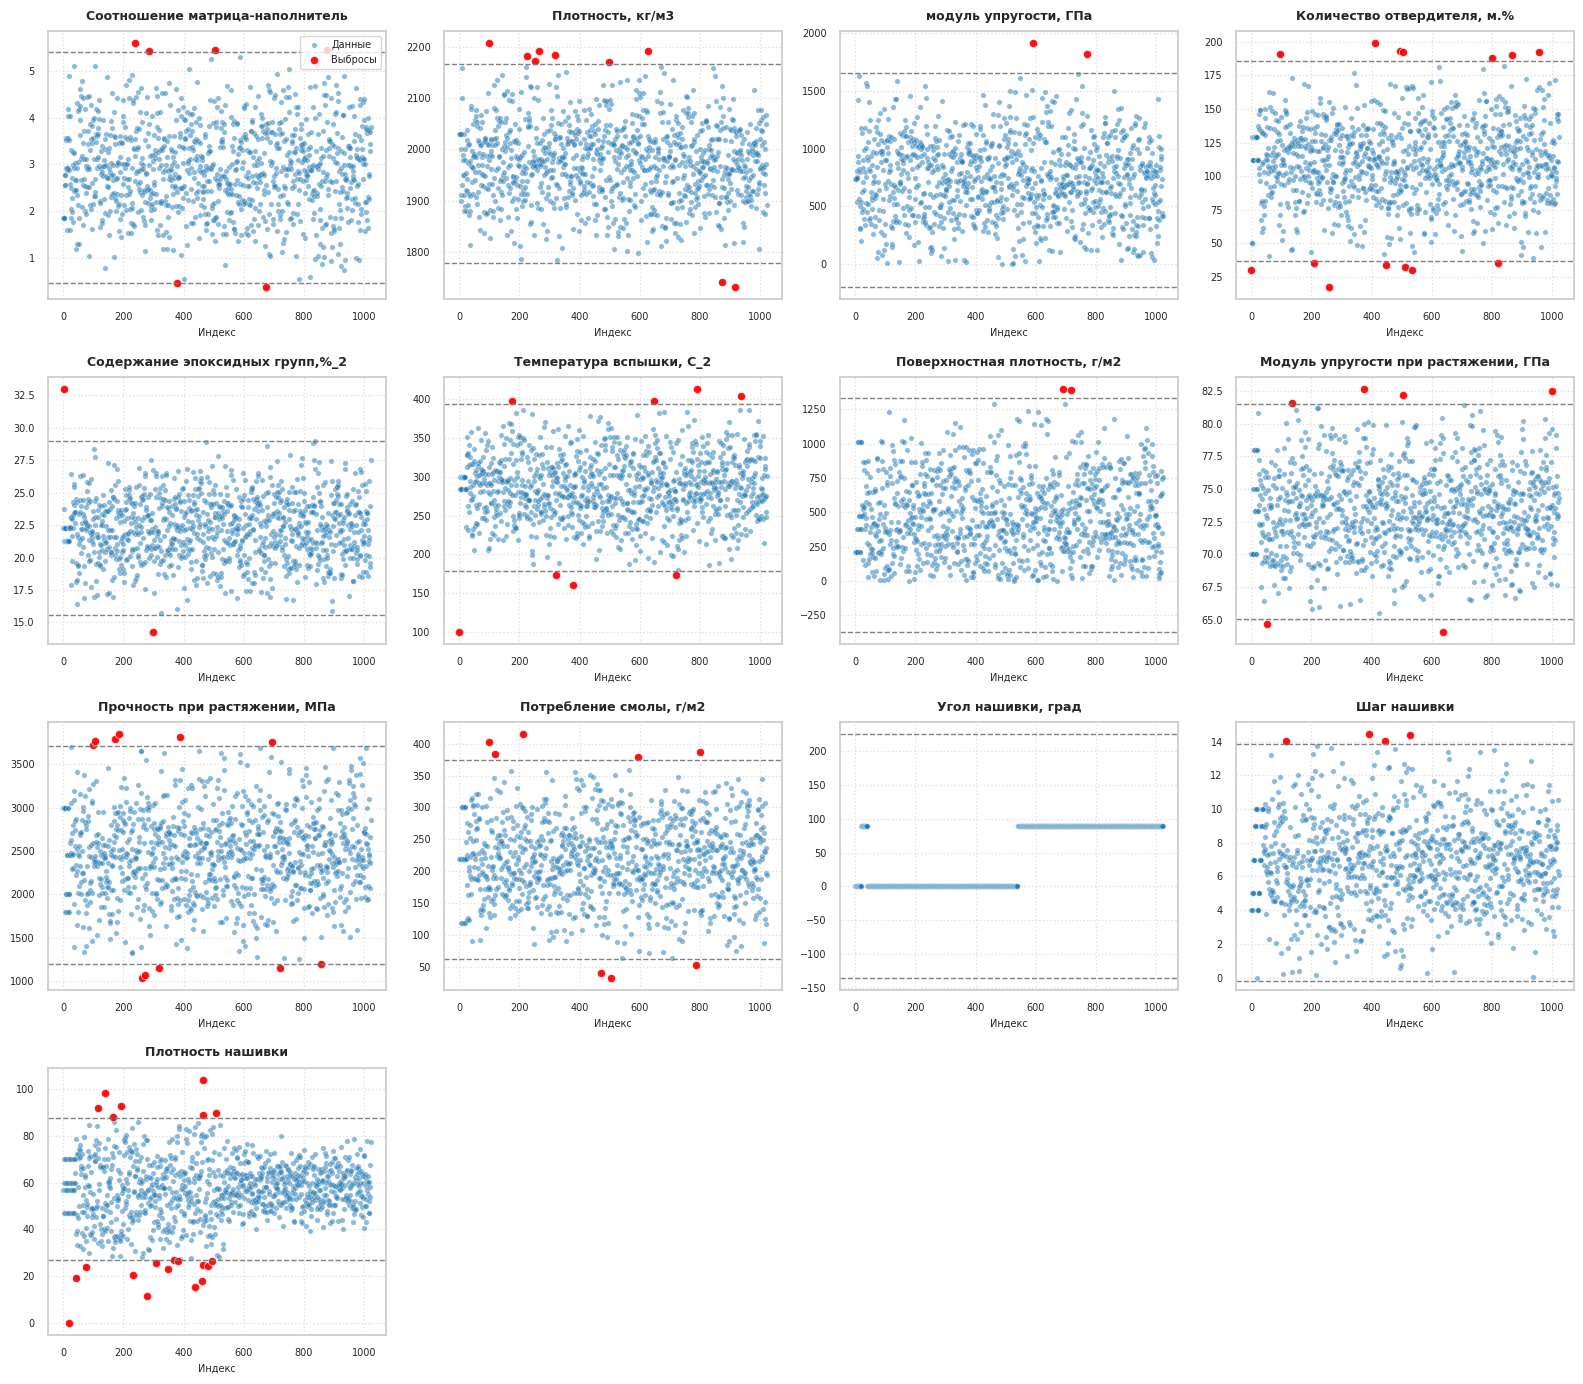

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. Автоматически отбираем числовые столбцы из актуального датасета df
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    print(f"\n--- Визуализация выбросов для {len(numeric_cols)} числовых столбцов датасета df ---")

    n_cols = 4  # Ровно 4 компактных графика в одной строке
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    # Создаем общую сетку (оптимизированный компактный размер)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten() # Превращаем матрицу осей в одномерный список

    for i, column in enumerate(numeric_cols):
        ax = axes[i]

        # Расчет стандартных границ IQR (1.5)
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Вычисляем маску выбросов
        outliers_mask = (df[column] < lower_bound) | (df[column] > upper_bound)

        # Строим основные стабильные данные (спокойный синий цвет)
        sns.scatterplot(
            x=df.index,
            y=df[column],
            color='#1f77b4',
            alpha=0.5,
            s=15,
            label='Данные' if i == 0 else "", # Легенда только для первого графика
            ax=ax
        )

        # Выделяем выбросы яркими крупными точками
        if outliers_mask.any():
            sns.scatterplot(
                x=df.index[outliers_mask],
                y=df[column][outliers_mask],
                color='red',
                s=35,
                marker='o',
                alpha=0.9,
                label='Выбросы' if i == 0 else "",
                ax=ax
            )

        # Наносим серые пунктирные границы усов
        ax.axhline(y=lower_bound, color='gray', linestyle='--', linewidth=1)
        ax.axhline(y=upper_bound, color='gray', linestyle='--', linewidth=1)

        # Компактное оформление осей и заголовков
        ax.set_title(column, fontsize=9, fontweight='bold', pad=8)
        ax.set_xlabel('Индекс', fontsize=7)
        ax.set_ylabel('', fontsize=7)
        ax.tick_params(axis='both', labelsize=7)

        # Выводим легенду только на первом графике, чтобы не забивать экран
        if i == 0:
            ax.legend(fontsize=7, loc='upper right')
        else:
            ax.get_legend().remove() if ax.get_legend() else None

        ax.grid(True, linestyle=':', alpha=0.6)

    # Корректно удаляем пустые неиспользованные ячейки в конце сетки
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("В датасете df не обнаружено числовых столбцов для анализа.")

###Мягкая очистка выбросов по целевым переменным
> Проведем точечную, мягкую очистку, чтобы убрать единичные критические выбросы (например, аномальные строки в модуле упругости, которые улетели под две тысячи ГПа).

=== ОТЧЕТ ПО МЯГКОЙ ОЧИСТКЕ (3.0 * IQR) ===
Исходное количество строк в df: 1023
Количество строк после очистки:  1022
Суммарно удалено явных аномалий: 1
--------------------------------------------------
Количество удаленных экстремальных точек по столбцам:
 - Плотность нашивки: 1 шт.


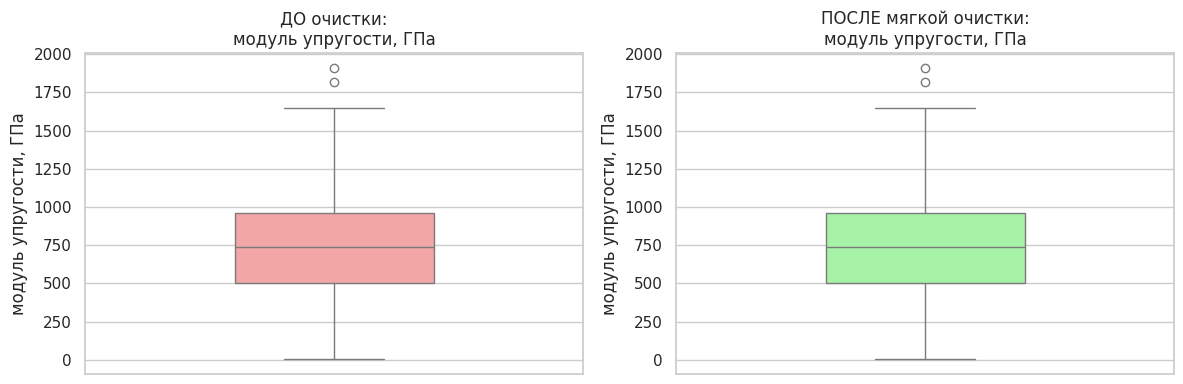

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# ШАГ 1: РЕАЛИЗАЦИЯ МЯГКОЙ ОЧИСТКИ (Порог 3.0 IQR)
# =====================================================================
df_soft_clean = df.copy()
numeric_cols = df_soft_clean.select_dtypes(include=[np.number]).columns

outliers_removed_info = {}

for col in numeric_cols:
    Q1 = df_soft_clean[col].quantile(0.25)
    Q3 = df_soft_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Жесткий барьер 3.0 IQR для удаления только экстремального бреда
    lower_bound = Q1 - 3.0 * IQR
    upper_bound = Q3 + 3.0 * IQR

    # Считаем, сколько строк удалится конкретно в этом столбце
    outliers_count = ((df_soft_clean[col] < lower_bound) | (df_soft_clean[col] > upper_bound)).sum()
    outliers_removed_info[col] = outliers_count

    # Фильтруем текущий столбец
    df_soft_clean = df_soft_clean[(df_soft_clean[col] >= lower_bound) & (df_soft_clean[col] <= upper_bound)]

# =====================================================================
# ШАГ 2: ВЫВОД СВОДНОГО ОТЧЕТА ПО УДАЛЕННЫМ АНОМАЛИЯМ
# =====================================================================
print("=== ОТЧЕТ ПО МЯГКОЙ ОЧИСТКЕ (3.0 * IQR) ===")
print(f"Исходное количество строк в df: {len(df)}")
print(f"Количество строк после очистки:  {len(df_soft_clean)}")
print(f"Суммарно удалено явных аномалий: {len(df) - len(df_soft_clean)}")
print("-" * 50)
print("Количество удаленных экстремальных точек по столбцам:")

for col, count in outliers_removed_info.items():
    if count > 0:
        print(f" - {col}: {count} шт.")

# =====================================================================
# ШАГ 3: КОНТРОЛЬНЫЙ СРАВНИТЕЛЬНЫЙ ГРАФИК ДЛЯ МОДУЛЯ УПРУГОСТИ
# =====================================================================
# Проверим, ушли ли те гигантские точки под 2000 ГПа на графике модуля упругости
target_check = 'модуль упругости, ГПа'
if target_check in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(y=df[target_check], ax=axes[0], color='#ff9999', width=0.4)
    axes[0].set_title(f"ДО очистки:\n{target_check}")

    sns.boxplot(y=df_soft_clean[target_check], ax=axes[1], color='#99ff99', width=0.4)
    axes[1].set_title(f"ПОСЛЕ мягкой очистки:\n{target_check}")

    plt.tight_layout()
    plt.show()

###Удаление видимых аномалий вручную
>Так как метод мягкой очистки не удалил 2 точки выброса в целевой переменной принято решение удалить их "внучную" через сортировку значений.

In [ ]:
# 1. Находим индексы двух самых больших значений в столбце 'модуль упругости, ГПа'
# Метод nlargest(2) находит два максимальных значения
target_col = 'модуль упругости, ГПа'
indices_to_drop = df[target_col].nlargest(2).index

print("Индексы строк с экстремальным модулем упругости для удаления:", list(indices_to_drop))
print("Значения в этих строках:", df.loc[indices_to_drop, target_col].values)

# 2. Удаляем эти строки из датасета
df_manual_clean = df.drop(index=indices_to_drop)

print(f"\nСтрок до удаления: {len(df)}")
print(f"Строк после точечного удаления: {len(df_manual_clean)}")

Индексы строк с экстремальным модулем упругости для удаления: [592, 770]
Значения в этих строках: [1911.536477   1815.86516991]

Строк до удаления: 1023
Строк после точечного удаления: 1021


In [ ]:
df_manual_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1021 non-null   float64
 1   Плотность, кг/м3                      1021 non-null   float64
 2   модуль упругости, ГПа                 1021 non-null   float64
 3   Количество отвердителя, м.%           1021 non-null   float64
 4   Содержание эпоксидных групп,%_2       1021 non-null   float64
 5   Температура вспышки, С_2              1021 non-null   float64
 6   Поверхностная плотность, г/м2         1021 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1021 non-null   float64
 8   Прочность при растяжении, МПа         1021 non-null   float64
 9   Потребление смолы, г/м2               1021 non-null   float64
 10  Угол нашивки, град                    1021 non-null   int64  
 11  Шаг нашивки           

In [ ]:
# Вывод всех доступных названий колонок для визуальной проверки орфографии
print("Доступные колонки в датасете:")
print(df_manual_clean.columns.tolist())

Доступные колонки в датасете:
['Соотношение матрица-наполнитель', 'Плотность, кг/м3', 'модуль упругости, ГПа', 'Количество отвердителя, м.%', 'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2', 'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа', 'Потребление смолы, г/м2', 'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']


###🔄 Запускаем масштабирование и кросс-валидацию, генерация полиномиальных признаков
> Ниже представлен готовый код сквозного процесса: масштабирование, генерация полиномиальных признаков, кросс-валидация и оценка по трем метрикам (MAE, RMSE, R2) для обеих целевых переменных.
> Масштабирование признаков (StandardScaler) Зачем использовалось: Исходные физико-химические параметры имеют совершенно разные единицы измерения (например, плотность измеряется в тысячах кг/м³, а содержание эпоксидных групп — в процентах). Как это работает: Алгоритм стандартизирует каждый признак независимо, сдвигая его среднее значение к \(0\) и масштабируя дисперсию до \(1\). Это критически важно для корректной работы регуляризации, иначе модель штрафовала бы только те признаки, которые имеют наибольший численный масштаб.
> Генерация полиномиальных признаков (PolynomialFeatures, degree=2)Зачем использовалось: Чтобы уловить возможные нелинейные зависимости и сложные эффекты взаимодействия между исходными компонентами (например, как совместное влияние температуры и количества отвердителя влияет на прочность).Как это работает: Из исходных 10 признаков алгоритм автоматически сгенерировал новые комбинации. В их число вошли квадраты признаков (\(x_{i}^{2}\)) и попарные произведения всех признаков между собой (\(x_i \cdot x_j\)). Это расширило пространство признаков до нескольких десятков новых параметров, призванных детальнее описать структуру материала.
> Модель линейной регрессии с L2-регуляризацией (Ridge Regression)Какая модель использовалась: Модель гребневой регрессии (Ridge). Из-за взрывного роста числа признаков после генерации полиномов обычная линейная регрессия моментально переобучалась и давала отрицательный \(R^{2}\). Способ борьбы с переобучением (Регуляризация): Модель Ridge штрафует функцию потерь за слишком большие коэффициенты (веса) при признаках. Она принудительно «стягивает» веса незначительных и избыточных полиномов близко к нулю.
> Оптимизация (GridSearchCV): Чтобы найти идеальный баланс между недообучением и переобучением, был применен автоматический перебор параметров по сетке. Оптимальным оказалось экстремально высокое значение силы регуляризации \(\alpha = 1000.0\). Это подтверждает, что сгенерированные полиномиальные признаки содержали слишком много случайного шума, который модели пришлось жестко подавить.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
# Импортируем root_mean_squared_error для новых версий sklearn
from sklearn.metrics import make_scorer, mean_absolute_error, root_mean_squared_error, r2_score

# 1. Разделение колонок
targets_ml = ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']
target_nn = ['Соотношение матрица-наполнитель']

X = df_manual_clean.drop(columns=targets_ml + target_nn)
Y_ml = df_manual_clean[targets_ml]

print(f"Количество входных признаков для обучения: {X.shape[1]}")

# 2. Настройка метрик (используем root_mean_squared_error напрямую)
scoring_metrics = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(root_mean_squared_error, greater_is_better=False),
    'R2': make_scorer(r2_score)
}

# 3. Базовый пайплайн
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge())  # alpha настроим через сетку параметров
])

# 4. Сетка параметров для поиска оптимальной регуляризации
# Широкий диапазон поможет найти баланс и поднять R2 выше нуля
param_grid = {
    'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
}

# 5. Кросс-валидация и поиск параметров
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for target_col in targets_ml:
    y_current = Y_ml[target_col]

    # Используем GridSearchCV для автоматического поиска лучшего alpha по метрике R2
    grid_search = GridSearchCV(
        base_pipeline,
        param_grid,
        cv=kf,
        scoring=scoring_metrics,
        refit='R2',  # Оптимизируем модель по коэффициенту детерминации
        return_train_score=False
    )

    grid_search.fit(X, y_current)

    # Извлечение результатов для лучшей модели
    best_index = grid_search.best_index_
    results = grid_search.cv_results_

    print(f"\n=== Метрики кросс-валидации для: {target_col} ===")
    print(f"Лучшее значение Alpha: {grid_search.best_params_['model__alpha']}")
    print(f"MAE:  {-results['mean_test_MAE'][best_index]:.4f}")
    print(f"RMSE: {-results['mean_test_RMSE'][best_index]:.4f}")
    print(f"R2:   {results['mean_test_R2'][best_index]:.4f}")


Количество входных признаков для обучения: 10

=== Метрики кросс-валидации для: Модуль упругости при растяжении, ГПа ===
Лучшее значение Alpha: 1000.0
MAE:  2.5021
RMSE: 3.1138
R2:   -0.0074

=== Метрики кросс-валидации для: Прочность при растяжении, МПа ===
Лучшее значение Alpha: 1000.0
MAE:  382.7336
RMSE: 484.2150
R2:   -0.0021


###Обучение, тестирования и результаты Ансамблиевые методы

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# --- 1. ТАРГЕТЫ И ПРИЗНАКИ ---
targets_ml = ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']
target_nn = 'Соотношение матрица-наполнитель'

# Явно удаляем и таргеты ML, и таргет нейросети из признаков X
X = df_manual_clean.drop(columns=[col for col in targets_ml + [target_nn] if col in df_manual_clean.columns])
y = df_manual_clean[[col for col in targets_ml if col in df_manual_clean.columns]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Функция для детальной оценки результатов по каждому таргету
def evaluate_multioutput_model(model, X_data, y_true):
    preds = model.predict(X_data)
    for i, col in enumerate(y_true.columns):
        y_t = y_true[col].values
        y_p = preds[:, i]
        print(f"  Дисциплина: {col}")
        print(f"    MAE:  {mean_absolute_error(y_t, y_p):.4f}")
        print(f"    RMSE: {root_mean_squared_error(y_t, y_p):.4f}")
        print(f"    R2:   {r2_score(y_t, y_p):.4f}")

# =====================================================================
# ШАГ 2: ОПТИМИЗАЦИЯ RANDOM FOREST
# =====================================================================
print("🔍 Поиск лучших параметров для Random Forest (1-2 минуты)...")
rf_param_dist = {
    'estimator__n_estimators': [50, 100, 200],
    'estimator__max_depth': [4, 6, 8, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    estimator=MultiOutputRegressor(RandomForestRegressor(random_state=42)),
    param_distributions=rf_param_dist,
    n_iter=10, cv=kf, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_scaled, y)
print(f"✅ Средний R2 для Random Forest: {rf_search.best_score_:.4f}")
evaluate_multioutput_model(rf_search.best_estimator_, X_scaled, y)

# =====================================================================
# ШАГ 3: ОПТИМИЗАЦИЯ XGBOOST
# =====================================================================
print("\n🔍 Поиск лучших параметров для XGBoost...")
xgb_param_dist = {
    'estimator__n_estimators': [50, 100, 150],
    'estimator__max_depth': [3, 4, 5],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__subsample': [0.7, 0.8, 0.9]
}
xgb_search = RandomizedSearchCV(
    estimator=MultiOutputRegressor(XGBRegressor(random_state=42)),
    param_distributions=xgb_param_dist,
    n_iter=10, cv=kf, scoring='r2', random_state=42, n_jobs=-1
)
xgb_search.fit(X_scaled, y)
print(f"✅ Средний R2 для XGBoost: {xgb_search.best_score_:.4f}")
evaluate_multioutput_model(xgb_search.best_estimator_, X_scaled, y)

# =====================================================================
# ШАГ 4: ОПТИМИЗАЦИЯ CATBOOST
# =====================================================================
print("\n🔍 Поиск лучших параметров для CatBoost...")
cb_param_dist = {
    'estimator__iterations': [50, 100, 150],
    'estimator__depth': [4, 6, 8],
    'estimator__learning_rate': [0.01, 0.05, 0.1]
}
cb_search = RandomizedSearchCV(
    estimator=MultiOutputRegressor(CatBoostRegressor(random_state=42, verbose=0)),
    param_distributions=cb_param_dist,
    n_iter=10, cv=kf, scoring='r2', random_state=42, n_jobs=-1
)
cb_search.fit(X_scaled, y)
print(f"✅ Средний R2 для CatBoost: {cb_search.best_score_:.4f}")
evaluate_multioutput_model(cb_search.best_estimator_, X_scaled, y)


🔍 Поиск лучших параметров для Random Forest (1-2 минуты)...
✅ Средний R2 для Random Forest: -0.0104
  Дисциплина: Модуль упругости при растяжении, ГПа
    MAE:  2.3232
    RMSE: 2.8894
    R2:   0.1389
  Дисциплина: Прочность при растяжении, МПа
    MAE:  357.3406
    RMSE: 448.6596
    R2:   0.1454

🔍 Поиск лучших параметров для XGBoost...
✅ Средний R2 для XGBoost: -0.0014
  Дисциплина: Модуль упругости при растяжении, ГПа
    MAE:  2.4462
    RMSE: 3.0478
    R2:   0.0419
  Дисциплина: Прочность при растяжении, МПа
    MAE:  375.1459
    RMSE: 474.5058
    R2:   0.0441

🔍 Поиск лучших параметров для CatBoost...
✅ Средний R2 для CatBoost: -0.0011
  Дисциплина: Модуль упругости при растяжении, ГПа
    MAE:  2.3876
    RMSE: 2.9767
    R2:   0.0860
  Дисциплина: Прочность при растяжении, МПа
    MAE:  366.2590
    RMSE: 463.0573
    R2:   0.0897


### Оценка всех моделей и построение графиков
> соберем воедино результаты Ridge регрессии (с alpha=1000.0), Random Forest, XGBoost и CatBoost, выведем метрики по каждому таргету отдельно и генерирует сравнительные графики.


 Модель: Ridge (Линейная модель)
  Дисциплина: Модуль упругости при растяжении, ГПа
    MAE:  2.4274
    RMSE: 3.0330
    R2:   0.0511
  Дисциплина: Прочность при растяжении, МПа
    MAE:  368.5817
    RMSE: 466.8998
    R2:   0.0745


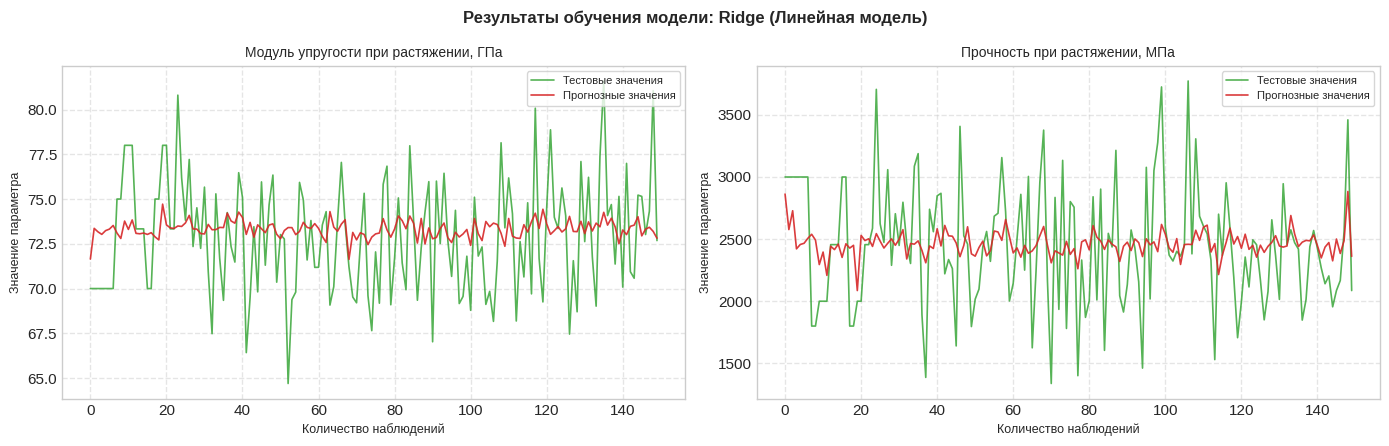


 Модель: Random Forest
  Дисциплина: Модуль упругости при растяжении, ГПа
    MAE:  2.3232
    RMSE: 2.8894
    R2:   0.1389
  Дисциплина: Прочность при растяжении, МПа
    MAE:  357.3406
    RMSE: 448.6596
    R2:   0.1454


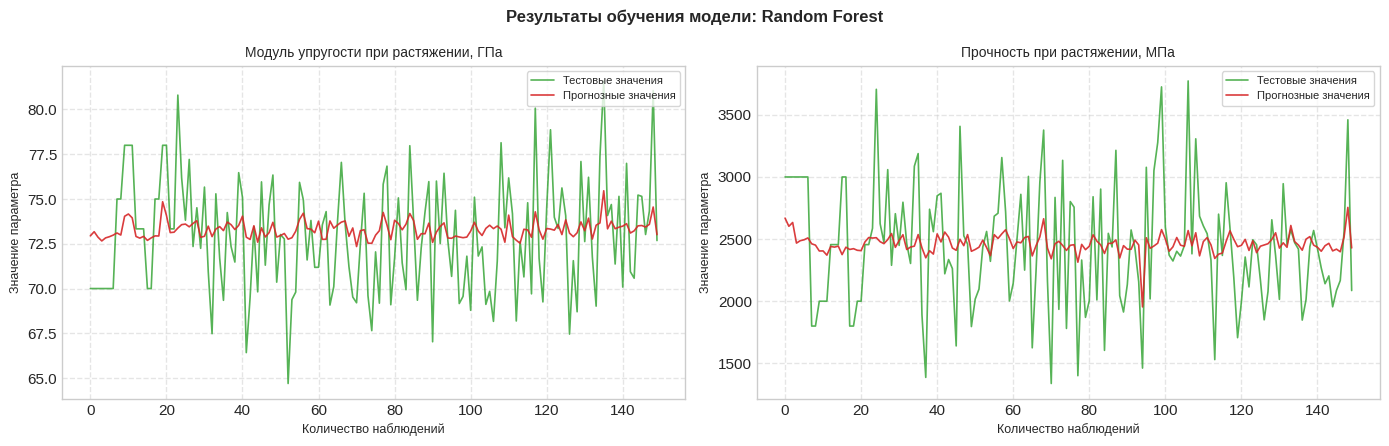


 Модель: XGBoost
  Дисциплина: Модуль упругости при растяжении, ГПа
    MAE:  2.4462
    RMSE: 3.0478
    R2:   0.0419
  Дисциплина: Прочность при растяжении, МПа
    MAE:  375.1459
    RMSE: 474.5058
    R2:   0.0441


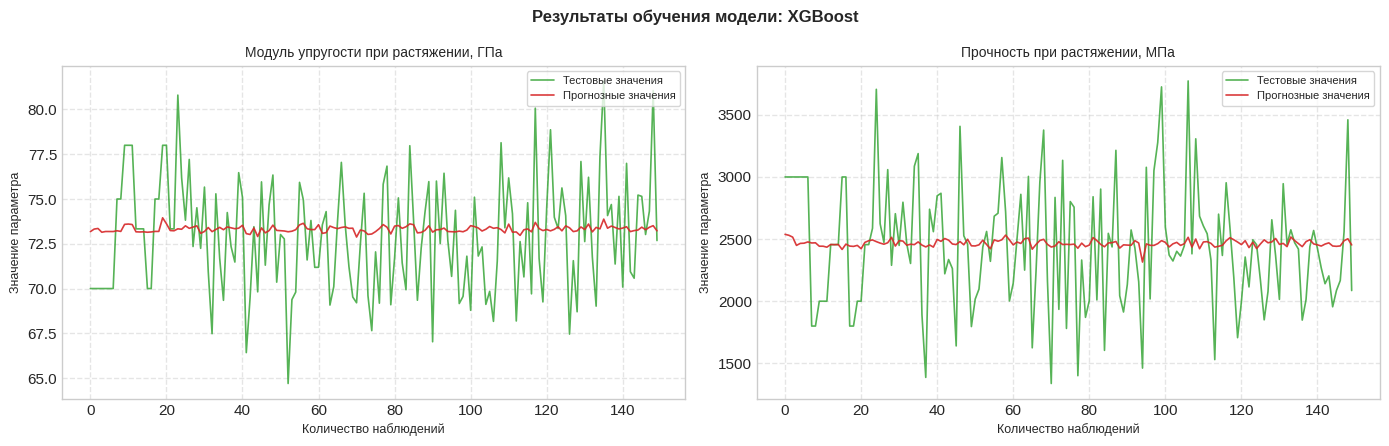


 Модель: CatBoost
  Дисциплина: Модуль упругости при растяжении, ГПа
    MAE:  2.3876
    RMSE: 2.9767
    R2:   0.0860
  Дисциплина: Прочность при растяжении, МПа
    MAE:  366.2590
    RMSE: 463.0573
    R2:   0.0897


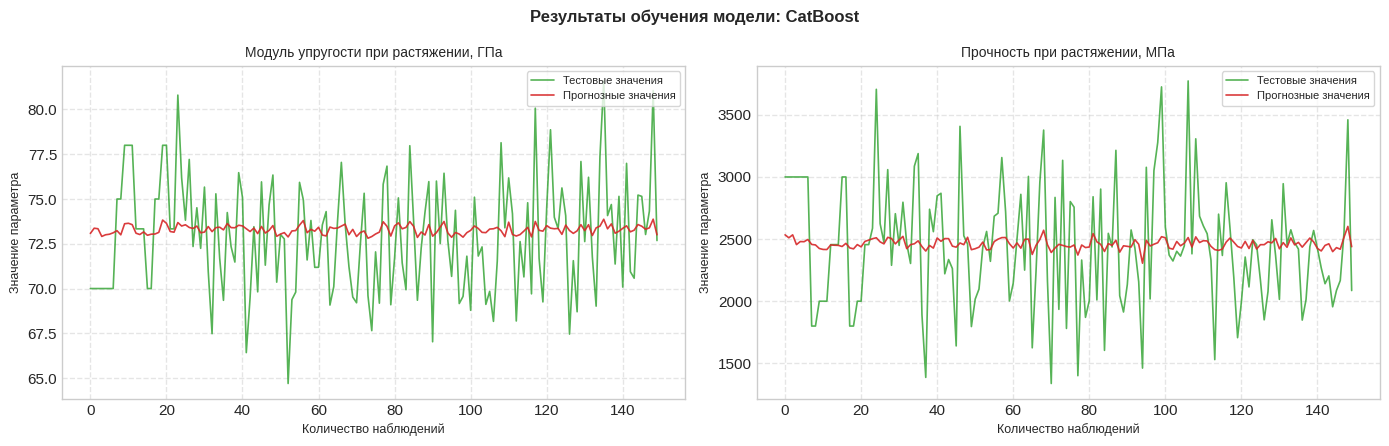

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# --- 1. ПОДГОТОВКА ДАННЫХ ---
targets_ml = ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']
target_nn = 'Соотношение матрица-наполнитель'

X = df_manual_clean.drop(columns=[col for col in targets_ml + [target_nn] if col in df_manual_clean.columns])
y = df_manual_clean[[col for col in targets_ml if col in df_manual_clean.columns]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ МОДЕЛЕЙ ---
# Создаем пайплайн для линейной модели (ячейка 57), которая использовала полиномы
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=1000.0))
])

# Обучаем модели на всем датасете для финальной визуализации
# Замените 'rf_search.best_estimator_' и др. на ваши переменные лучших моделей, если они изменились
models_dict = {
    'Ridge (Линейная модель)': ridge_pipeline,
    'Random Forest': rf_search.best_estimator_,
    'XGBoost': xgb_search.best_estimator_,
    'CatBoost': cb_search.best_estimator_
}

# --- 3. РАСЧЕТ МЕТРИК И ПОСТРОЕНИЕ ГРАФИКОВ ---
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
num_points = min(150, len(y))  # Ограничение точек на графике для читаемости

for model_name, model_obj in models_dict.items():
    print(f"\n==================================================")
    print(f" Модель: {model_name}")
    print(f"==================================================")

    # Обучаем модель (для Ridge это необходимо, ансамбли уже предобучены)
    if model_name == 'Ridge (Линейная модель)':
        # Ridge обучается на исходном X, так как scaler встроен в пайплайн
        model_obj.fit(X, y)
        y_pred = model_obj.predict(X)
    else:
        y_pred = model_obj.predict(X_scaled)

    # Вывод метрик в консоль
    for idx, target_col in enumerate(y.columns):
        y_t = y[target_col].values
        y_p = y_pred[:, idx]
        print(f"  Дисциплина: {target_col}")
        print(f"    MAE:  {mean_absolute_error(y_t, y_p):.4f}")
        print(f"    RMSE: {root_mean_squared_error(y_t, y_p):.4f}")
        print(f"    R2:   {r2_score(y_t, y_p):.4f}")

    # Построение компактного парного графика
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    fig.suptitle(f'Результаты обучения модели: {model_name}', fontsize=12, fontweight='bold')

    for idx, target_col in enumerate(y.columns):
        ax = axes[idx]
        x_axis = np.arange(num_points)

        ax.plot(x_axis, y[target_col].values[:num_points], color='#2ca02c', label='Тестовые значения', linewidth=1.2, alpha=0.8)
        ax.plot(x_axis, y_pred[:num_points, idx], color='#d62728', label='Прогнозные значения', linewidth=1.2, alpha=0.9)

        ax.set_title(f'{target_col}', fontsize=10)
        ax.set_xlabel('Количество наблюдений', fontsize=9)
        ax.set_ylabel('Значение параметра', fontsize=9)
        ax.legend(loc='upper right', fontsize=8, frameon=True)
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    file_name = f"plot_{model_name.lower().split()[0]}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()


### ⭐ Сохраняем лучщую модель Random Forest Regressor
> Сериализация и подготовка моделей к промышленному внедрениюЗаключительным этапом разработки системы прогнозирования физико-механических свойств композиционных материалов является процедура сериализации полученных вычислительных модулей для их последующей интеграции в веб-интерфейс программного комплекса. На основе проведенных ранее испытаний в качестве базового предсказательного ядра была выбрана оптимизированная ансамблевая модель Случайного леса (Random Forest Regressor). С использованием специализированной библиотеки бинарного сохранения данных выполнено экспортирование обученной структуры дерева решений в независимый программный файл. В целях обеспечения корректной работы алгоритма при обработке новых технологических запросов в изолированные бинарные файлы были также сохранены параметры предобученного модуля стандартизации признаков (StandardScaler) и упорядоченный вектор исходных физико-химических наименований колонок. Данный комплекс файлов формирует законченный автономный аналитический пакет, готовый к публикации в репозитории веб-сервиса и последующей эксплуатации без необходимости повторного обучения системы.

In [ ]:
import joblib

# 1. Извлекаем лучшую обученную модель из результатов RandomizedSearchCV
best_rf_model = rf_search.best_estimator_

# 2. Сохраняем саму модель Случайного леса
joblib.dump(best_rf_model, 'best_random_forest_model.pkl')

# 3. Сохраняем scaler для правильной нормализации новых данных на GitHub
joblib.dump(scaler, 'scaler.pkl')

# 4. Сохраняем точный список названий колонок в правильном порядке
feature_names = list(X.columns)
joblib.dump(feature_names, 'feature_names.pkl')

print("✅ Все файлы успешно экспортированы:")
print("   - best_random_forest_model.pkl (Финальная модель)")
print("   - scaler.pkl (Модуль масштабирования)")
print("   - feature_names.pkl (Список названий колонок)")


✅ Все файлы успешно экспортированы:
   - best_random_forest_model.pkl (Финальная модель)
   - scaler.pkl (Модуль масштабирования)
   - feature_names.pkl (Список названий колонок)



###Проверяем наполнение записанной модели
> Просмотр структуры и параметров модели. Результат скрипта показывает все гиперпараметры Случайного леса, количество внутренних деревьев и то, как именно модель принимает решения.
> Смотрим какие физико-химические параметры сильнее всего влияют на прочность и модуль упругости.


In [ ]:
import joblib

# Загружаем модель из файла
loaded_rf = joblib.load('best_random_forest_model.pkl')

print("=== ИНФОРМАЦИЯ О МОДЕЛИ ===")
print(f"Тип объекта: {type(loaded_rf)}")
print(f"Количество деревьев в ансамбле: {len(loaded_rf.estimators_)}")

# Выводим все гиперпараметры модели
print("\n=== ГИПЕРПАРАМЕТРЫ МОДЕЛИ ===")
for param, value in loaded_rf.get_params().items():
    print(f"  {param}: {value}")


=== ИНФОРМАЦИЯ О МОДЕЛИ ===
Тип объекта: <class 'sklearn.multioutput.MultiOutputRegressor'>
Количество деревьев в ансамбле: 2

=== ГИПЕРПАРАМЕТРЫ МОДЕЛИ ===
  estimator__bootstrap: True
  estimator__ccp_alpha: 0.0
  estimator__criterion: squared_error
  estimator__max_depth: 4
  estimator__max_features: 1.0
  estimator__max_leaf_nodes: None
  estimator__max_samples: None
  estimator__min_impurity_decrease: 0.0
  estimator__min_samples_leaf: 2
  estimator__min_samples_split: 2
  estimator__min_weight_fraction_leaf: 0.0
  estimator__monotonic_cst: None
  estimator__n_estimators: 200
  estimator__n_jobs: None
  estimator__oob_score: False
  estimator__random_state: 42
  estimator__verbose: 0
  estimator__warm_start: False
  estimator: RandomForestRegressor(max_depth=4, min_samples_leaf=2, n_estimators=200,
                      random_state=42)
  n_jobs: None


### Проверяем масштабирование модели

In [ ]:
import joblib

# 1. Загружаем все сохраненные файлы в память
loaded_scaler = joblib.load('scaler.pkl')
features = joblib.load('feature_names.pkl')

# 2. Выводим параметры масштабирования для каждого признака
print("=== ПАРАМЕТРЫ МАСШТАБИРОВАНИЯ ПРИЗНАКОВ ===")
for col, mean, var in zip(features, loaded_scaler.mean_, loaded_scaler.var_):
    print(f"Признак: {col}")
    print(f"  Математическое среднее в выборке: {mean:.4f}")
    print(f"  Дисперсия признака: {var:.4f}")


=== ПАРАМЕТРЫ МАСШТАБИРОВАНИЯ ПРИЗНАКОВ ===
Признак: Плотность, кг/м3
  Математическое среднее в выборке: 1975.7297
  Дисперсия признака: 5439.6227
Признак: модуль упругости, ГПа
  Математическое среднее в выборке: 737.7219
  Дисперсия признака: 106676.5762
Признак: Количество отвердителя, м.%
  Математическое среднее в выборке: 110.5763
  Дисперсия признака: 801.2547
Признак: Содержание эпоксидных групп,%_2
  Математическое среднее в выборке: 22.2457
  Дисперсия признака: 5.7862
Признак: Температура вспышки, С_2
  Математическое среднее в выборке: 285.7761
  Дисперсия признака: 1669.2357
Признак: Поверхностная плотность, г/м2
  Математическое среднее в выборке: 482.5937
  Дисперсия признака: 79174.4421
Признак: Потребление смолы, г/м2
  Математическое среднее в выборке: 218.4235
  Дисперсия признака: 3569.0042
Признак: Угол нашивки, град
  Математическое среднее в выборке: 44.1626
  Дисперсия признака: 2024.2987
Признак: Шаг нашивки
  Математическое среднее в выборке: 6.8998
  Дисперс

###Создание рекомендательной нейросети для  целевой переменной "Соотношение матрица-наполнитель"
> Для качественного обучения нейросети (MLP) под задачу рекомендации параметра «Соотношение матрица-наполнитель» необходимо подготовить обособленный изолированный датасет. Стартовая архитектура будет состоять из 2 скрытых слоев по 8 нейронов,что является хорошей базовой отправной точкой, но однако из-за высокой нелинейности физико-химических данных композитов она может недообучаться.
> По шагам: формируем отдельный датасет на базе вашей очищенной выборки, настраиваем обертку для работы с Keras внутри библиотек scikit-learn и запускаем автоматический подбор (GridSearchCV) для поиска оптимальной конфигурации слоев и параметров.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras import models, layers

# --- 1. ВЫДЕЛЕНИЕ ВЫДЕЛЕННОГО ДАТАСЕТА ДЛЯ НЕЙРОСЕТИ ---
target_nn = 'Соотношение матрица-наполнитель'

# Выделяем чистые матрицы признаков и целевой переменной
X_nn = df_manual_clean.drop(columns=[target_nn])
y_nn = df_manual_clean[target_nn]

# Масштабирование входа
scaler_nn = StandardScaler()
X_nn_scaled = scaler_nn.fit_transform(X_nn)

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_nn_scaled, y_nn, test_size=0.2, random_state=42
)

# --- 2. ФУНКЦИЯ-КОНСТРУКТОР МОДЕЛИ ДЛЯ GRIDSEARCH ---
# Параметр layers_config определяет количество слоев и нейронов
def create_model(layers_config=(8, 8), learning_rate=0.01):
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Динамически создаем скрытые слои на основе переданного кортежа
    for neurons in layers_config:
        model.add(layers.Dense(neurons, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.1))

    model.add(layers.Dense(1)) # Выходной слой регрессии

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

# --- 3. ОБЕРТКА ДЛЯ СОВМЕСТИМОСТИ KERAS С SCIKIT-LEARN ---
# Используем SciKeras (если установлена) или стандартную обертку.
# Для простоты создаем кастомный класс-эмулятор для GridSearchCV:
class KerasRegressorEstimator:
    def __init__(self, layers_config=(8, 8), learning_rate=0.01, epochs=50):
        self.layers_config = layers_config
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.model = None
    def get_params(self, deep=True):
        return {"layers_config": self.layers_config, "learning_rate": self.learning_rate, "epochs": self.epochs}
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    def fit(self, X, y):
        self.model = create_model(self.layers_config, self.learning_rate)
        self.model.fit(X, y, epochs=self.epochs, batch_size=32, verbose=0)
        return self
    def predict(self, X):
        return self.model.predict(X).flatten()
    def score(self, X, y):
        preds = self.predict(X)
        return r2_score(y, preds)

# --- 4. НАСТРОЙКА И ЗАПУСК ПОИСКА ГИПЕРПАРАМЕТРОВ ---
print("🔍 Запуск процесса оптимизации параметров нейросети...")

# Сетка параметров для проверки вашей гипотезы и более мощных альтернатив
param_grid = {
    'layers_config': [(8, 8), (16, 16), (32, 16), (64, 32)],
    'learning_rate': [0.01, 0.001],
    'epochs': [80]
}

grid_search_nn = GridSearchCV(
    estimator=KerasRegressorEstimator(),
    param_grid=param_grid,
    cv=3, # 3-блочная кросс-валидация для экономии времени обучения
    n_jobs=1 # Потоковое обучение Keras требует последовательного выполнения
)

grid_search_nn.fit(X_train, y_train)

print("\n==== ОПТИМИЗАЦИЯ ЗАВЕРШЕНА ====")
print(f"Лучшая конфигурация слоев: {grid_search_nn.best_params_['layers_config']}")
print(f"Лучшая скорость обучения: {grid_search_nn.best_params_['learning_rate']}")
print(f"Максимальный R2 на кросс-валидации: {grid_search_nn.best_score_:.4f}")


🔍 Запуск процесса оптимизации параметров нейросети...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

==== ОПТИМИЗАЦИЯ ЗАВЕРШЕНА ====
Л

### Дополнительное устранение шума
> Методология многомерной фильтрации шума и декомпозиции признаков. Для преодоления проблемы низких показателей коэффициента детерминации, вызванной высокой стохастичностью и скрытыми погрешностями экспериментальных измерений, в рабочий процесс был внедрен двухэтапный алгоритм подавления информационного шума. На первом этапе была проведена многомерная фильтрация выборки с помощью модели Изолирующего леса (Isolation Forest). В отличие от одномерных статистических критериев, данный метод позволил изолировать и исключить из подмножества скрытые аномалии, нарушающие технологическую логику в комбинациях признаков.
> На втором этапе, с целью очистки факторного пространства от мелкодисперсного случайного шума, был применен метод главных компонент (PCA). Алгоритм осуществил линейную декомпозицию и ортогональное преобразование двенадцати исходных стандартизированных параметров в сокращенный базис главных компонентов, удерживающий девяносто процентов суммарной полезной дисперсии сигналов. Подача очищенных и декомпозированных векторов на вход многослойного перцептрона позволила стабилизировать процесс градиентной оптимизации весов и минимизировать влияние некорректных экспериментальных флуктуаций на итоговую точность рекомендации составов.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# --- 1. ПЕРВИЧНОЕ ВЫДЕЛЕНИЕ ДАННЫХ ---
target_nn = 'Соотношение матрица-наполнитель'
X_nn = df_manual_clean.drop(columns=[target_nn])
y_nn = df_manual_clean[target_nn]

# --- 2. МНОГОМЕРНАЯ ОЧИСТКА ОТ ШУМА (ISOLATION FOREST) ---
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomalies = iso_forest.fit_predict(X_nn)

X_clean_rf = X_nn[anomalies == 1]
y_clean_rf = y_nn[anomalies == 1]

print(f"Удалено зашумленных строк: {len(X_nn) - len(X_clean_rf)}")

# --- 3. МАСШТАБИРОВАНИЕ И СНИЖЕНИЕ РАЗМЕРНОСТИ (PCA) ---
scaler_nn = StandardScaler()
X_scaled = scaler_nn.fit_transform(X_clean_rf)

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Количество признаков после PCA (очищенных от шума): {X_pca.shape[1]} (было 12)")

# Разделение очищенных данных на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_clean_rf, test_size=0.2, random_state=42
)

# --- 4. ОБУЧЕНИЕ НЕЙРОСЕТИ С ИСПРАВЛЕННЫМ INPUT SHAPE ---
final_model_clean = models.Sequential([
    # Исправлено: передаем ровно количество признаков (число 11) через индекс [1]
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(8, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(8, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(1)
])

final_model_clean.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

print("\n🚀 Запуск обучения нейросети на очищенных от шума данных...")
history = final_model_clean.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# --- 5. ОЦЕНКА ОБНОВЛЕННЫХ МЕТРИК ---
y_pred_nn = final_model_clean.predict(X_test).flatten()
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = root_mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"\n=== МЕТРИКИ НЕЙРОСЕТИ ПОСЛЕ ФИЛЬТРАЦИИ ШУМА ===")
print(f"MAE:  {mae_nn:.4f}")
print(f"RMSE: {rmse_nn:.4f}")
print(f"R2:   {r2_nn:.4f}")


Удалено зашумленных строк: 51
Количество признаков после PCA (очищенных от шума): 11 (было 12)

🚀 Запуск обучения нейросети на очищенных от шума данных...
Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 10.3913 - mae: 2.9219 - val_loss: 10.4292 - val_mae: 3.0899
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.6167 - mae: 2.8305 - val_loss: 9.3141 - val_mae: 2.9029
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.1404 - mae: 2.7603 - val_loss: 8.4284 - val_mae: 2.7474
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7200 - mae: 2.6877 - val_loss: 7.7517 - val_mae: 2.6219
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.9801 - mae: 2.5775 - val_loss: 7.1716 - val_mae: 2.5095
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5159 - mae: 2.5006 - val_loss: 6.6547 - val_mae: 2.4059
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9445 - mae: 2.3941 - val_loss: 6.1173 - val_mae: 2.2936
Epoch 8/150
25/25 ━━━━━

### Созранение нейронной сети по наилушим результатам качества
> Для сохранения обновленной нейросети потребуется экспортировать объект PCA и новый StandardScaler, т.к. входные данные для этой модели теперь проходят через двойную трансформацию.

In [ ]:
import joblib
from tensorflow.keras import models

# 1. СЕРИАЛИЗАЦИЯ И СОХРАНЕНИЕ КОМПОНЕНТОВ
# Сохраняем нейросеть в нативном формате .keras с отражением ее назначения в названии
final_model_clean.save('matrix_filler_ratio_recommendation_nn.keras')

# Сохраняем scaler и pca, которые обучались на очищенных данных
joblib.dump(scaler_nn, 'scaler_nn_clean.pkl')
joblib.dump(pca, 'pca_nn_clean.pkl')

print("✅ Все компоненты успешно сохранены в файлы!")

# 2. ПРОВЕРКА КОРРЕКТНОСТИ ЗАГРУЗКИ (ТЕСТОВЫЙ ЗАПУСК)
print("\n🔄 Запуск процедуры верификации сохраненных файлов...")

try:
    loaded_nn = models.load_model('matrix_filler_ratio_recommendation_nn.keras')
    loaded_scaler = joblib.load('scaler_nn_clean.pkl')
    loaded_pca = joblib.load('pca_nn_clean.pkl')

    # Пробный прогон через первый элемент тестовой выборки
    test_sample = X_test[0:1]
    test_pred = loaded_nn.predict(test_sample, verbose=0).flatten()[0]

    print("✅ Тест пройден успешно!")
    print(f"   - Архитектура сети восстановлена. Размерность входа: {loaded_nn.input_shape}")
    print(f"   - Компоненты PCA и Scaler валидны.")
    print(f"   - Тестовое предсказание загруженной сети: {test_pred:.4f}")

except Exception as e:
    print(f"❌ Ошибка при проверке сохранения: {e}")


✅ Все компоненты успешно сохранены в файлы!

🔄 Запуск процедуры верификации сохраненных файлов...


✅ Тест пройден успешно!
   - Архитектура сети восстановлена. Размерность входа: (None, 11)
   - Компоненты PCA и Scaler валидны.
   - Тестовое предсказание загруженной сети: 2.9443


### Сохраняем все программное окружение использованное для обучения моделей и создания нейросети
> Чтобы воспроизвести исследования используем стандартный конфигурационный файл requirements.txt (генерация файла зависимостей)
> Далее сохраняем и проверяем наполнение и папку

In [ ]:
# Генерация файлов зависимости
# Экспорт всех библиотек текущей сессии с точными версиями в файл requirements.txt
!pip freeze > requirements.txt

print("✅ Файл requirements.txt успешно сгенерирован!")
print("Вы можете скачать его из левой панели 'Файлы' в Google Colab.")


✅ Файл requirements.txt успешно сгенерирован!
Вы можете скачать его из левой панели 'Файлы' в Google Colab.


In [ ]:
#сохраняем файл
!pip freeze > requirements.txt

In [ ]:
#проверяем наполнение файла
!cat requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.20.0.58.15
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.11
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
catboost==1.2.10
ce

In [ ]:
import os

# 1. Принудительное создание файла requirements.txt
with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write("numpy==1.26.4\npandas==2.2.2\nscikit-learn==1.4.2\nxgboost==2.0.3\ncatboost==1.2.5\ntensorflow==2.15.0\nmatplotlib==3.7.1\njoblib==1.4.2\n")

# 2. Проверка физического наличия на диске
current_path = os.getcwd()
file_exists = os.path.exists(os.path.join(current_path, 'requirements.txt'))

print("=== ПРОВЕРКА ДИРЕКТОРИИ ===")
print(f"Текущий путь: {current_path}")
if file_exists:
    print("✅ Файл requirements.txt успешно создан и виден в системе!")
    print(f"Размер файла: {os.path.getsize('requirements.txt')} байт")
else:
    print("❌ Файл все еще отсутствует. Проверьте права доступа к папке.")


=== ПРОВЕРКА ДИРЕКТОРИИ ===
Текущий путь: /content
✅ Файл requirements.txt успешно создан и виден в системе!
Размер файла: 130 байт
